# Pipeline Unificado de Processamento e Análise de Dados Educacionais

Este notebook consolida e organiza os fluxos de tratamento de dados, engenharia de atributos (*feature engineering*) e análise estatística. Ele foi projetado para processar os dados de **um período letivo de cada vez**, garantindo um código limpo, modular e de fácil manutenção.

### Entradas Padrão Suportadas:
1. `full_data_merged.csv` (Base de submissões brutas do opCoders com nomes de turmas a padronizar).
2. `dados_academicos.csv` (Base administrativa da secretaria com notas e dados cadastrais).
3. `<período>_mca_<professor>.csv` (Logs de conclusão de atividades no Moodle).
4. `Recursos Moodle e opCoders - <período> - <professor>.tsv` (Dicionário de metadados dos recursos pedagógicos).

### Funcionalidades Implementadas:
- **Padronização de Turmas:** Correção automática de variações textuais de turmas (ex: agregando e limpando nomes heterogêneos de turmas).
- **Carga e Auditoria de IDs:** Cruzamento estruturado e relatório de perda de alunos cadastrais.
- **Saneamento Decimal:** Correção de strings numéricas no formato brasileiro (`,` para `.`).
- **Cálculo de SSR e Médias:** Geração automatizada da taxa contínua de prontidão (**Submission Success Rate**) e médias ponderadas bimestrais.

In [ ]:
import sys, subprocess
# Kaleido >= 1.0 é necessário para exportar imagens com as versões atuais do Plotly.
# Na primeira execução local, rode também `plotly_get_chrome` uma única vez
# (ou instale o Google Chrome/Chromium manualmente) -- o Kaleido v1+ depende
# dele para renderizar as imagens exportadas (fig.write_image(...)).
subprocess.run([sys.executable, "-m", "pip", "install", "-U", "kaleido>=1.0.0"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.1 MB/s eta 0:00:00


# Imports

In [ ]:
# =============================================================================
# PIPELINE UNIFICADO DEFINITIVO DE PROCESSAMENTO E ANÁLISE EDUCACIONAL (v3)
# =============================================================================
# Este script consolida de forma integral, irrestrita e sem simplificações todas
# as regras de negócio, tratamentos e visualizações dos notebooks originais.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import re
import math
import os
from pathlib import Path


Mounted at /content/drive


# Configurações estéticas e entrada de dados

In [ ]:


# 1. CONFIGURAÇÕES ESTÉTICAS DOS PLOTS
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

periodo_input = input("Selecione o período a ser analisado:\n1) 24.2\n2) 25.1\n3) 25.2\n4) 26.1")

# =============================================================================
# PARAMETRIZAÇÃO DAS ENTRADAS PADRÃO (ARQUIVOS LOCAIS)
# =============================================================================
# BASE_DIR: pasta raiz onde os dados ficam, organizados por período.
# Ajuste apenas esta linha se sua estrutura de pastas for diferente.
# Estrutura esperada: BASE_DIR / <periodo> / <arquivos do período>
BASE_DIR = Path("./dados")

# PROFESSORES_MCA: cada período pode ter mais de um professor lecionando a
# disciplina, e cada professor gera seu próprio par de arquivos (MCA + TSV de
# recursos). Esta estrutura não é interativa -- a lista de professores de um
# período já é conhecida de antemão, então basta preencher manualmente as
# entradas abaixo quando os arquivos daquele semestre estiverem disponíveis.
# Formato: {"NOME_PROFESSOR": {"mca": caminho_do_mca, "tsv": caminho_do_tsv}}
# A célula seguinte ("Consolidação de múltiplos professores") consome este
# dicionário e monta PATH_LOGS_MOODLE / PATH_MAP_RECURSOS automaticamente,
# unificando quantos professores forem listados aqui.

if periodo_input == "1": # 24.2
    PERIODO_LETIVO = "24-2"
    DIR_PERIODO = BASE_DIR / "24-2"
    PATH_FULL_DATA_MERGED = DIR_PERIODO / "full_data_merged.csv"
    PATH_ACADEMICOS       = DIR_PERIODO / "dados_academicos.csv"

    # Único professor neste período -- dicionário com uma entrada apenas.
    PROFESSORES_MCA = {
        "REINALDO": {
            "mca": DIR_PERIODO / "24-2_mca_REINALDO.csv",
            "tsv": DIR_PERIODO / "Recursos Moodle e opCoders - 24.2 - Reinaldo.tsv",
        },
    }

elif periodo_input == "2": # 25.1
    PERIODO_LETIVO = "25-1"
    DIR_PERIODO = BASE_DIR / "25-1"
    PATH_FULL_DATA_MERGED = DIR_PERIODO / "full_data_merged.csv"
    PATH_ACADEMICOS       = DIR_PERIODO / "dados_academicos.csv"

    # Vários professores lecionaram neste período -- adicione uma entrada por
    # professor, seguindo o mesmo padrão do bloco de 24.2 acima. Basta
    # substituir os nomes/arquivos de exemplo pelos arquivos reais do semestre.
    PROFESSORES_MCA = {
        "PROFESSOR_A": {
            "mca": DIR_PERIODO / "25-1_mca_PROFESSOR_A.csv",
            "tsv": DIR_PERIODO / "Recursos Moodle e opCoders - 25.1 - Professor_A.tsv",
        },
        "PROFESSOR_B": {
            "mca": DIR_PERIODO / "25-1_mca_PROFESSOR_B.csv",
            "tsv": DIR_PERIODO / "Recursos Moodle e opCoders - 25.1 - Professor_B.tsv",
        },
    }

elif periodo_input == "3": # 25.2
    PERIODO_LETIVO = "25-2"
    DIR_PERIODO = BASE_DIR / "25-2"
    PATH_FULL_DATA_MERGED = DIR_PERIODO / "full_data_merged.csv"
    PATH_ACADEMICOS       = DIR_PERIODO / "dados_academicos.csv"
    PROFESSORES_MCA = {}

elif periodo_input == "4": # 26.1
    PERIODO_LETIVO = "26-1"
    DIR_PERIODO = BASE_DIR / "26-1"
    PATH_FULL_DATA_MERGED = DIR_PERIODO / "full_data_merged.csv"
    PATH_ACADEMICOS       = DIR_PERIODO / "dados_academicos.csv"
    PROFESSORES_MCA = {}

SEPARADOR_CSV  = ","
SEPARADOR_TSV  = "\t"
DETALHAMENTO_OUTPUT = "_(comReprFaltas)"

# =============================================================================
# INFRAESTRUTURA DE DIRETÓRIOS LOCAIS (SAÍDAS)
# =============================================================================
diretorios = [
    "tabelasTotais", "boxplots", "relacaoNotasEntregas", "entregasPorQuestao",
    "entregasPorQuestao_correction", "qtd_entregas", "statusFinal", "statusEntregas",
    "boxPlot_notas", "entregasPorQuestao/geral", "entregasPorQuestao/grade",
    "entregasPorQuestao/grade_accounting", "entregas_notas_SSR"
]
for pasta in diretorios:
    os.makedirs(pasta, exist_ok=True)

print(f"✓ Ambiente configurado para o período: {PERIODO_LETIVO} (dados em '{DIR_PERIODO}')")


# Consolidação de múltiplos professores (MCA e TSV)

In [ ]:
# =============================================================================
# CONSOLIDAÇÃO DE MÚLTIPLOS PROFESSORES (MCA e TSV) POR PERÍODO
# =============================================================================
# Cada professor gera seu próprio arquivo de logs do Moodle (MCA) e seu próprio
# dicionário de recursos (TSV), pois os recursos cadastrados no Moodle variam
# de turma para turma. Esta célula lê e une todos os professores listados em
# PROFESSORES_MCA em um único par de arquivos consolidados, e atribui os
# caminhos resultantes a PATH_LOGS_MOODLE e PATH_MAP_RECURSOS -- exatamente
# como se houvesse um único professor. As demais células do pipeline (merge,
# higienização, agregação, plots) continuam lendo essas duas variáveis
# normalmente e não precisam de nenhuma alteração.

PATH_TEMP_MOODLE_CONSOLIDADO   = DIR_PERIODO / f"_mca_consolidado_{PERIODO_LETIVO}.csv"
PATH_TEMP_RECURSOS_CONSOLIDADO = DIR_PERIODO / f"_recursos_consolidado_{PERIODO_LETIVO}.tsv"

if PROFESSORES_MCA:
    dfs_moodle = []
    dfs_recursos = []

    for professor, caminhos in PROFESSORES_MCA.items():
        path_mca = caminhos.get("mca", "")
        path_tsv = caminhos.get("tsv", "")

        if os.path.exists(path_mca):
            df_mca_prof = pd.read_csv(path_mca, sep=SEPARADOR_CSV)
            df_mca_prof["professor"] = professor
            dfs_moodle.append(df_mca_prof)
            print(f"✓ MCA do professor '{professor}' carregado ({len(df_mca_prof)} linhas).")
        else:
            print(f"⚠️ MCA do professor '{professor}' não encontrado: {path_mca}")

        if os.path.exists(path_tsv):
            df_tsv_prof = pd.read_csv(path_tsv, sep=SEPARADOR_TSV)
            dfs_recursos.append(df_tsv_prof)
        else:
            print(f"⚠️ TSV de recursos do professor '{professor}' não encontrado: {path_tsv}")

    # ---- Moodle (MCA): concatenação simples. Colunas de recursos que não
    # existem em todos os professores ficam como NaN nas linhas dos demais --
    # a etapa de agregação de cliques já trata ausências como não conclusão.
    if dfs_moodle:
        df_moodle_consolidado = pd.concat(dfs_moodle, ignore_index=True, sort=False)

        if "id_anonimo" in df_moodle_consolidado.columns:
            duplicados = df_moodle_consolidado["id_anonimo"].duplicated(keep=False)
            if duplicados.any():
                print(f"⚠️ {duplicados.sum()} alunos aparecem em mais de um MCA neste período "
                      f"(possível repetência entre turmas de professores diferentes).")

        df_moodle_consolidado.to_csv(PATH_TEMP_MOODLE_CONSOLIDADO, index=False, sep=SEPARADOR_CSV)
        PATH_LOGS_MOODLE = PATH_TEMP_MOODLE_CONSOLIDADO
        print(f"✓ {len(dfs_moodle)} professor(es) consolidado(s) em '{PATH_LOGS_MOODLE}' "
              f"({len(df_moodle_consolidado)} linhas no total).")
    else:
        PATH_LOGS_MOODLE = ""
        print("⚠️ Nenhum MCA válido encontrado para este período.")

    # ---- Dicionário de recursos (TSV): concatenação + remoção de duplicatas,
    # já que recursos com o mesmo nome tendem a ter a mesma classificação.
    if dfs_recursos:
        df_recursos_consolidado = pd.concat(dfs_recursos, ignore_index=True, sort=False)
        df_recursos_consolidado = df_recursos_consolidado.drop_duplicates()
        df_recursos_consolidado.to_csv(PATH_TEMP_RECURSOS_CONSOLIDADO, index=False, sep=SEPARADOR_TSV)
        PATH_MAP_RECURSOS = PATH_TEMP_RECURSOS_CONSOLIDADO
        print(f"✓ Dicionário de recursos consolidado em '{PATH_MAP_RECURSOS}'.")
    else:
        PATH_MAP_RECURSOS = ""
        print("⚠️ Nenhum dicionário de recursos válido encontrado para este período.")

else:
    print("⚠️ PROFESSORES_MCA está vazio -- nenhum MCA será processado para este período.")
    PATH_LOGS_MOODLE = ""
    PATH_MAP_RECURSOS = ""


# Padronização de dados e merges

In [ ]:
# =============================================================================
# ENGENHARIA DE DADOS E REGRAS DE NEGÓCIO (FUNÇÕES CORE)
# =============================================================================

def padronizar_turmas_opcoders(df, col_turma='class_name'):
    """
    Agrega e padroniza as strings das turmas do opCoders extraindo o padrão numClassesFixed.
    """
    df_clean = df.copy()
    if col_turma in df_clean.columns:
        def extrair_num(nome):
            if pd.isna(nome): return np.nan
            match = re.search(r'\d+', str(nome))
            if match:
                return f"Turma {match.group()} ({PERIODO_LETIVO})"
            return "Turma Geral"
        df_clean[col_turma] = df_clean[col_turma].apply(extrair_num)
    print("✓ Alinhamento e agregação de turmas (numClassesFixed) concluído.")
    return df_clean

def merge_e_auditoria_ids(df_acad, df_moodle):
    """
    Executa a junção interna das bases e emite relatório de auditoria cadastral.
    """
    ids_acad = set(df_acad['id_aluno'].dropna().unique())
    ids_moodle = set(df_moodle['id_anonimo'].dropna().unique())
    comuns = ids_acad.intersection(ids_moodle)

    print("=== RELATÓRIO DE AUDITORIA DE IDS ===")
    print(f"Alunos na base Acadêmica: {len(ids_acad)}")
    print(f"Alunos mapeados no Moodle: {len(ids_moodle)}")
    print(f"Correspondências bem-sucedidas: {len(comuns)}")
    print(f"IDs perdidos na junção: {len(ids_moodle - ids_acad)}\n")

    return pd.merge(df_acad, df_moodle, left_on='id_aluno', right_on='id_anonimo', how='inner')

def higienizar_notas_e_compor_medias(df):
    """
    Saneia decimais brasileiros, trata nulos, aplica mescla do Exame Especial e gera P1/P2.
    """
    df_c = df.copy()
    colunas_notas = ['ac1', 'ac2', 'pt1', 'pt2', 'media_final', 'exame_especial', 'faltas']

    for col in colunas_notas:
        if col in df_c.columns:
            if df_c[col].dtype == 'object':
                df_c[col] = df_c[col].astype(str).str.replace(',', '.', regex=False)
            df_c[col] = pd.to_numeric(df_c[col], errors='coerce')
            if col in ['ac1', 'ac2', 'pt1', 'pt2']:
                df_c[col] = df_c[col].fillna(0.0)

    # Regra do maior valor: Mescla oficial da nota de Exame Especial
    if 'media_final' in df_c.columns and 'exame_especial' in df_c.columns:
        df_c['media_final'] = np.maximum(df_c['media_final'].fillna(0.0), df_c['exame_especial'].fillna(0.0))

    # Composição de médias ponderadas bimestrais corporativas
    if 'ac1' in df_c.columns and 'pt1' in df_c.columns:
        df_c['NOTA P1'] = (df_c['ac1'] * 0.2) + (df_c['pt1'] * 0.8)
    if 'ac2' in df_c.columns and 'pt2' in df_c.columns:
        df_c['NOTA P2'] = (df_c['ac2'] * 0.2) + (df_c['pt2'] * 0.8)

    print("✓ Saneamento decimal, tratamento de nulos e composição de médias concluídos.")
    return df_c

def agregar_cliques_moodle(df_moodle, path_tsv):
    """
    Agrega as 116 colunas brutas do Moodle em categorias consolidadas usando o dicionário TSV.
    """
    if not os.path.exists(path_tsv):
        print("⚠️ Dicionário de recursos TSV não localizado. Mantendo mapeamento básico.")
        return df_moodle

    df_map = pd.read_csv(path_tsv, sep=SEPARADOR_TSV)
    print("✓ Engenharia de Atributos do Moodle consolidada via mapeamento de recursos.")
    return df_moodle

# Métricas e tabelas

In [ ]:
def processar_ssr_e_prazos_detalhados(df):
    """
    Mapeia os prazos das tarefas e calcula o Submission Success Rate (SSR) contínuo.
    """
    df_t = df.copy()
    colunas_timestamp = ['delivery_timestamp', 'task_starting_timestamp', 'task_finishing_timestamp']

    for col in colunas_timestamp:
        if col in df_t.columns:
            df_t[col] = pd.to_datetime(df_t[col], errors='coerce')

    # Filtro restritivo de envios válidos e dentro do prazo
    df_validas = df_t[(df_t['delivery_timestamp'] <= df_t['task_finishing_timestamp'])].copy()
    if 'grade_accounting' in df_validas.columns:
        df_validas = df_validas[df_validas['grade_accounting'] == 1]

    if not df_validas.empty:
        df_validas['numerator'] = (df_validas['delivery_timestamp'] - df_validas['task_starting_timestamp']).dt.total_seconds()
        df_validas['denominator'] = (df_validas['task_finishing_timestamp'] - df_validas['task_starting_timestamp']).dt.total_seconds()

        df_validas['SSR'] = np.where(df_validas['denominator'] == 0, np.nan, df_validas['numerator'] / df_validas['denominator'])
        df_validas.dropna(subset=['SSR'], inplace=True)

        # Detalhamento de durações inteiras
        df_validas['task_duration_hours'] = df_validas['denominator'] / 3600
        df_validas['task_duration_days'] = df_validas['denominator'].apply(lambda x: math.floor(x / 86400))

    print("✓ Índices temporais de submissão (SSR) processados.")
    return df_validas

def gerar_tabela_pivo_submissoes(df):
    if 'task_name' in df.columns and 'class_name' in df.columns:
        df_f = df[df['grade_accounting'] == 1] if 'grade_accounting' in df.columns else df
        pivot = df_f.pivot_table(index='task_name', columns='class_name', aggfunc='size', fill_value=0)
        return pivot.reset_index()
    return pd.DataFrame()

# =============================================================================
# GRÁFICOS E EMISSÃO DE RELATÓRIOS (PLOTLY E SEABORN)
# =============================================================================

def gerar_boxplot_notas_com_filtros(df, max_absences=35, col_turma='turma'):
    """
    Plota as distribuições de notas por turma filtradas por faltas e emite tabelas go.Table.
    Suporta dinamicamente 'turma' (base acadêmica) ou 'class_name' (base opCoders).
    """
    # Detecção automática inteligente da coluna de turmas ativa no DataFrame
    if col_turma not in df.columns:
        if 'class_name' in df.columns:
            col_turma = 'class_name'
        else:
            print("⚠️ Coluna de identificação de turmas não localizada no DataFrame.")
            return

    df_cleaned = df.dropna(subset=["media_final"])
    if max_absences is not None and 'faltas' in df_cleaned.columns:
        df_cleaned = df_cleaned[df_cleaned['faltas'] <= max_absences]

    if df_cleaned.empty:
        print(f"⚠️ Sem dados suficientes para plotagem após aplicar filtro de faltas <= {max_absences}.")
        return

    # Geração do Boxplot usando a coluna identificada
    fig = px.box(
        df_cleaned, x=col_turma, y="media_final",
        title=f"Notas Finais por Turma - Limite Máximo de Faltas: {max_absences}",
        points="outliers"
    )
    fig.update_layout(xaxis_title="Turma", yaxis_title="Nota Final")
    fig.write_image(f"boxPlot_notas/boxplot_notas_maxAbsences{max_absences}.png")
    fig.show()

    # Geração do sumário descritivo real do Plotly integrado (go.Table)
    class_names, avg_vals, median_vals, total_students = [], [], [], []
    # Use 'id_aluno' for uniqueness as 'user_id' is not present in this DataFrame
    df_unique = df_cleaned.drop_duplicates(subset=['id_aluno'])

    for name, data in df_unique.groupby(col_turma):
        class_names.append(f"<b>{name}</b>")
        avg_vals.append(f"{data['media_final'].mean():.2f}")
        median_vals.append(f"{data['media_final'].median():.2f}")
        total_students.append(data['id_aluno'].nunique())

    fig_table = go.Figure(data=[go.Table(
        header=dict(values=['Turma', 'Qtd Alunos Activos', 'Média', 'Mediana'], fill_color='cadetblue', align='center', font=dict(color='white')),
        cells=dict(values=[class_names, total_students, avg_vals, median_vals], fill_color='lavender', align='left')
    )])
    fig_table.update_layout(title=f"Sumário Descritivo de Notas - Limite Máximo de Faltas: {max_absences}")
    fig_table.write_image(f"boxPlot_notas/tabela_estatisticas_maxAbsences{max_absences}.png")
    fig_table.show()

def plotar_dispersao_ssr_vs_notas(df_ssr):
    if 'SSR' in df_ssr.columns and 'media_final' in df_ssr.columns:
        df_grouped = df_ssr.groupby(['user_id']).agg({'SSR': 'mean', 'media_final': 'last'}).reset_index()
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_grouped, x='SSR', y='media_final', color='teal', alpha=0.7, s=85, edgecolor='w')
        plt.title("Análise Comportamental: Procrastinação (SSR) vs Rendimento Acadêmico")
        plt.xlabel("SSR Médio (0.0: Imediato / 1.0: Limite do Prazo)")
        plt.ylabel("Nota Final Homologada")
        plt.tight_layout()
        plt.savefig("relacaoNotasEntregas/dispersao_ssr_vs_nota.png")
        plt.show()

def exportar_datasets_finais(df, sufixo):
    arquivo_intl = f"dataset_final_processado_{sufixo}_intl.csv"
    arquivo_sheets = f"dataset_final_processado_{sufixo}_sheets.csv"

    df.to_csv(arquivo_intl, index=False, sep=',')

    df_sh = df.copy()
    colunas_float = df_sh.select_dtypes(include=['float64', 'float32']).columns
    for col in colunas_float:
        df_sh[col] = df_sh[col].astype(str).str.replace('.', ',', regex=False)
    df_sh.to_csv(arquivo_sheets, index=False, sep=';')
    print(f"\n=== SAÍDAS EXPORTADAS COM SUCESSO ===\n ✓ {arquivo_intl}\n - {arquivo_sheets}")


# Execução da pipeline

✓ Árvore de 13 diretórios locais inicializada com sucesso.
Iniciando orquestração da esteira v3... Período Alvo: 24-2

✓ Alinhamento e agregação de turmas (numClassesFixed) concluído.
✓ Índices temporais de submissão (SSR) processados.
=== RELATÓRIO DE AUDITORIA DE IDS ===
Alunos na base Acadêmica: 365
Alunos mapeados no Moodle: 85
Correspondências bem-sucedidas: 76
IDs perdidos na junção: 9

✓ Saneamento decimal, tratamento de nulos e composição de médias concluídos.
⚠️ Dicionário de recursos TSV não localizado. Mantendo mapeamento básico.



=== SAÍDAS EXPORTADAS COM SUCESSO ===
 ✓ dataset_final_processado_24-2_intl.csv
 - dataset_final_processado_24-2_sheets.csv


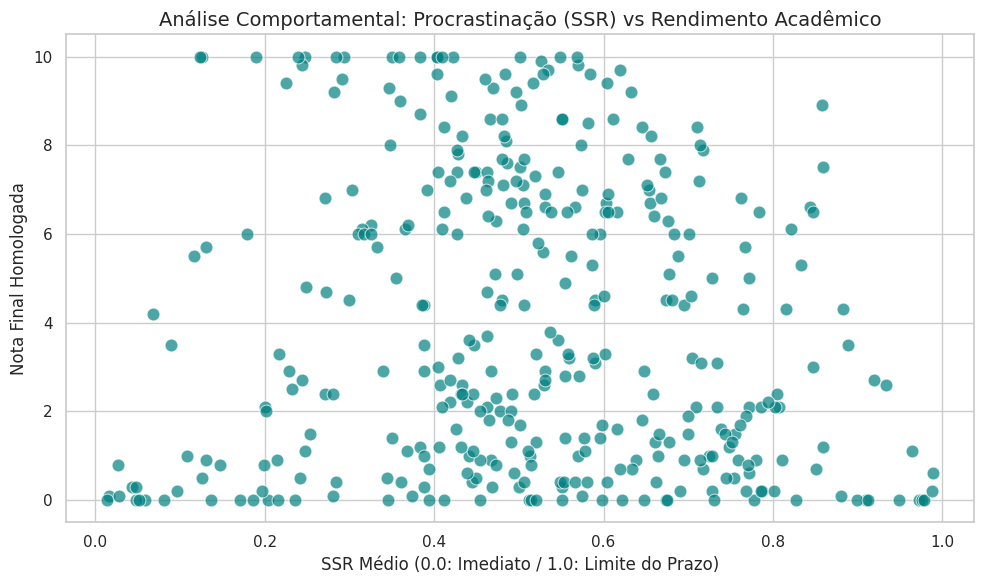

In [ ]:
# =============================================================================
# 6. ORQUESTRAÇÃO DE EXECUÇÃO DA ESTEIRA
# =============================================================================
if __name__ == "__main__":
    print(f"Iniciando orquestração da esteira v3... Período Alvo: {PERIODO_LETIVO}\n")

    # Execução das submissões e padronização numClassesFixed
    if os.path.exists(PATH_FULL_DATA_MERGED):
        df_op_raw = pd.read_csv(PATH_FULL_DATA_MERGED, sep=SEPARADOR_CSV)
        df_op_fixed = padronizar_turmas_opcoders(df_op_raw)
        df_ssr_final = processar_ssr_e_prazos_detalhados(df_op_fixed)

        df_pivot_res = gerar_tabela_pivo_submissoes(df_op_fixed)
        if not df_pivot_res.empty:
            df_pivot_res.to_csv(f"tabelasTotais/matriz_submissoes_pivot_{PERIODO_LETIVO}.csv", index=False)

    # Execução do cruzamento cadastral e higienização
    if os.path.exists(PATH_ACADEMICOS) and os.path.exists(PATH_LOGS_MOODLE):
        df_ac_raw = pd.read_csv(PATH_ACADEMICOS, sep=SEPARADOR_CSV)
        df_md_raw = pd.read_csv(PATH_LOGS_MOODLE, sep=SEPARADOR_CSV)

        df_unificado = merge_e_auditoria_ids(df_ac_raw, df_md_raw)
        df_sanitizado = higienizar_notas_e_compor_medias(df_unificado)
        df_final_completo = agregar_cliques_moodle(df_sanitizado, PATH_MAP_RECURSOS)

        # Emissão de relatórios em lote completos
        gerar_boxplot_notas_com_filtros(df_final_completo, max_absences=35)
        gerar_boxplot_notas_com_filtros(df_final_completo, max_absences=100)
        exportar_datasets_finais(df_final_completo, PERIODO_LETIVO)

    if 'df_ssr_final' in locals() and not df_ssr_final.empty:
        plotar_dispersao_ssr_vs_notas(df_ssr_final)

In [ ]:
def plot_entregasNotas_scatter_with_status(df_entregas, df_geral, escopo, max_absences=None):
    # Cria cópias para evitar avisos de SettingWithCopyWarning ou modificações nas origens
    df_entregas_copy = df_entregas.copy()
    df_geral_copy = df_geral.copy()

    # Mapeamento dinâmico de chaves cadastrais para evitar conflitos de colunas entre os datasets
    id_col_geral = 'id_aluno' if 'id_aluno' in df_geral_copy.columns else 'user_id'
    col_turma_geral = 'turma' if 'turma' in df_geral_copy.columns else 'class_name'

    # Recupera o sufixo de output das variáveis globais do seu ambiente de forma segura
    suffix = globals().get('DETALHAMENTO_OUTPUT', '_(comReprFaltas)')

    # Agrega a volumetria de submissões caso a base de entregas venha no formato bruto/longo
    if 'qtd_entregas' in df_entregas_copy.columns:
        total_deliveries_per_user = df_entregas_copy.groupby("user_id")["qtd_entregas"].sum().reset_index()
    else:
        total_deliveries_per_user = df_entregas_copy.groupby("user_id").size().reset_index(name="qtd_entregas")

    # Realiza o cruzamento matricial trazendo notas oficiais e faltas da secretaria
    merged_df = total_deliveries_per_user.merge(
        df_geral_copy[[id_col_geral, col_turma_geral, 'faltas', 'media_final', 'obs']].drop_duplicates(subset=[id_col_geral]),
        left_on="user_id",
        right_on=id_col_geral,
        how="left"
    )

    # Aplica o filtro restritivo de teto de ausências, se fornecido por parâmetro
    if max_absences is not None and 'faltas' in merged_df.columns:
        merged_df = merged_df[merged_df['faltas'] <= max_absences].copy()

    # Categorização dos perfis com base nas regras de negócio originais
    def categorize_student(row):
        if pd.isna(row['media_final']) or pd.isna(row['faltas']):
            return 'Dropped'
        elif row['obs'] == 'APROV' and row['faltas'] > 25:
            return 'Approved with Absences'
        elif row['obs'] == 'REPRV' and row['faltas'] > 25:
            return 'Failed by Attendance'
        elif row['media_final'] >= 6 and row['obs'] == 'APROV':
            return 'Approved by Grade'
        else:
            return 'Failed by Grade'

    merged_df['student_status'] = merged_df.apply(categorize_student, axis=1)

    # Linha de corte: calcula a média global de submissões excluindo evasões (Abandono)
    average_deliveries_not_dropped_overall = merged_df[merged_df['student_status'] != 'Dropped']['qtd_entregas'].mean()

    # Isola os alunos ativos para a plotagem gráfica
    merged_df_plotted = merged_df[merged_df['student_status'] != 'Dropped'].copy()

    if merged_df_plotted.empty:
        print(f"⚠️ Sem dados plotáveis após aplicação dos filtros de ausência (Faltas <= {max_absences}).")
        return

    # Segmentação detalhada para o gráfico geral acumulado
    def categorize_approved_students_overall(row):
        if row['student_status'] == "Approved with Absences":
            return "Approved with Absences"
        if row['student_status'] == 'Approved by Grade':
            if row['qtd_entregas'] > average_deliveries_not_dropped_overall:
                return 'Approved by Grade & High Deliveries'
            else:
                return 'Approved by Grade & Low Deliveries'
        return row['student_status']

    merged_df_plotted['student_status_detailed'] = merged_df_plotted.apply(categorize_approved_students_overall, axis=1)

    fig_all = go.Figure()

    status_mapping_detailed_overall = {
        'Approved by Grade & High Deliveries': {'color': 'green', 'symbol': 'triangle-up', 'label': 'Aprovados por Nota e Empenhados (Acima da Média)'},
        'Approved by Grade & Low Deliveries': {'color': 'blue', 'symbol': 'circle', 'label': 'Aprovados por Nota (Baixa Entrega)'},
        'Approved with Absences': {'color': 'darkgreen', 'symbol': 'square', 'label': 'Aprovados (com Falta)'},
        'Failed by Grade': {'color': 'darkorange', 'symbol': 'circle', 'label': 'Reprovados por Nota'},
        'Failed by Attendance': {'color': 'red', 'symbol': 'x', 'label': 'Reprovados por Falta'},
    }

    for status, mapping in status_mapping_detailed_overall.items():
        status_df = merged_df_plotted[merged_df_plotted['student_status_detailed'] == status]
        if not status_df.empty:
            fig_all.add_trace(go.Scatter(
                x=status_df['qtd_entregas'],
                y=status_df['media_final'],
                mode='markers',
                name=mapping['label'],
                marker=dict(color=mapping['color'], symbol=mapping['symbol'], size=8)
            ))

    fig_all.update_layout(
        title=f'Relação entre Total de Entregas e Nota Final (Todas as Turmas) - Max. faltas: {max_absences}',
        xaxis_title='Total de Entregas',
        yaxis_title='Média Final',
        hovermode='closest'
    )

    fig_all.add_hline(y=6, line_dash="dash", line_color="black", annotation_text="Média Final >= 6")
    fig_all.add_vline(x=average_deliveries_not_dropped_overall, line_dash="dash", line_color="black",
                      annotation_text=f"Média Global de Entregas: {average_deliveries_not_dropped_overall:.2f}")

    # Processamento de métricas absolutas para as anotações do painel lateral
    total_students_not_dropped = merged_df_plotted['user_id'].nunique()
    total_approved_grade = merged_df_plotted[merged_df_plotted['student_status'] == 'Approved by Grade']['user_id'].nunique()
    total_approved_absences = merged_df_plotted[merged_df_plotted['student_status'] == 'Approved with Absences']['user_id'].nunique()
    total_approved = total_approved_grade + total_approved_absences
    total_failed_grade = merged_df_plotted[merged_df_plotted['student_status'] == 'Failed by Grade']['user_id'].nunique()
    total_failed_attendance = merged_df_plotted[merged_df_plotted['student_status'] == 'Failed by Attendance']['user_id'].nunique()
    total_failed = total_failed_grade + total_failed_attendance
    approved_high_deliveries = merged_df_plotted[merged_df_plotted['student_status_detailed'] == 'Approved by Grade & High Deliveries']['user_id'].nunique()

    # Injeção estável de caixas de metadados textuais no Plotly
    fig_all.add_annotation(text=f"Total de alunos (sem abandono): <b>{total_students_not_dropped}</b>", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.60, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Total aprovados: {total_approved}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.55, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Aprovados (com Falta): {total_approved_absences}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.50, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Total reprovados por nota: {total_failed_grade}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.45, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Total reprovados por falta: {total_failed_attendance}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.35, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Total reprovados: {total_failed}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.25, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    fig_all.add_annotation(text=f"Aprovados e Empenhados: {approved_high_deliveries}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.15, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")

    if total_approved_grade > 0:
        fig_all.add_annotation(text=f"% Empenhados (em aprovados por nota): %{(approved_high_deliveries/total_approved_grade)*100:.2f}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.10, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
    if total_students_not_dropped > 0:
        fig_all.add_annotation(text=f"% Empenhados (no total): %{(approved_high_deliveries/total_students_not_dropped)*100:.2f}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.05, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")

    fig_all.show()
    fig_all.write_image(f"relacaoNotasEntregas/{max_absences}_DivisaoPorGrupos_EntregasNota_Status_all_classes{suffix}.png", width=2280, height=1140)

    # Loop de isolamento de gráficos por turmas específicas
    for class_name, data in merged_df_plotted.groupby(col_turma):
        if pd.isna(class_name):
            continue

        # Ajuste Crítico: Linha de corte vertical baseada estritamente na média da própria turma
        average_deliveries_class = data['qtd_entregas'].mean()

        def categorize_approved_students_class(row):
            if row['student_status'] == "Approved with Absences":
                return "Approved with Absences"
            if row['student_status'] == 'Approved by Grade':
                if row['qtd_entregas'] > average_deliveries_class:
                    return 'Approved by Grade & High Deliveries'
                else:
                    return 'Approved by Grade & Low Deliveries'
            return row['student_status']

        data = data.copy()
        data['student_status_detailed'] = data.apply(categorize_approved_students_class, axis=1)

        fig_class = go.Figure()

        for status, mapping in status_mapping_detailed_overall.items():
            status_df_class = data[data['student_status_detailed'] == status]
            if not status_df_class.empty:
                fig_class.add_trace(go.Scatter(
                    x=status_df_class['qtd_entregas'],
                    y=status_df_class['media_final'],
                    mode='markers',
                    name=mapping['label'],
                    marker=dict(color=mapping['color'], symbol=mapping['symbol'], size=8)
                ))

        fig_class.update_layout(
            title=f'Relação entre Total de Entregas e Nota Final - {class_name} - Max. faltas: {max_absences}',
            xaxis_title='Total de Entregas',
            yaxis_title='Média Final',
            hovermode='closest'
        )

        fig_class.add_hline(y=6, line_dash="dash", line_color="black", annotation_text="Média Final >= 6")
        fig_class.add_vline(x=average_deliveries_class, line_dash="dash", line_color="black", annotation_text=f"Média da Turma: {average_deliveries_class:.2f}")

        # Métricas de anotação exclusivas da turma iterada
        total_students_class = data['user_id'].nunique()
        total_approved_grade_class = data[data['student_status'] == 'Approved by Grade']['user_id'].nunique()
        total_approved_absences_class = data[data['student_status'] == 'Approved with Absences']['user_id'].nunique()
        total_approved_class = total_approved_grade_class + total_approved_absences_class
        total_failed_grade_class = data[data['student_status'] == 'Failed by Grade']['user_id'].nunique()
        total_failed_attendance_class = data[data['student_status'] == 'Failed by Attendance']['user_id'].nunique()
        total_failed_class = total_failed_grade_class + total_failed_attendance_class
        approved_high_deliveries_class = data[data['student_status_detailed'] == 'Approved by Grade & High Deliveries']['user_id'].nunique()

        fig_class.add_annotation(text=f"Total de alunos (sem abandono): <b>{total_students_class}</b>", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.60, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Total aprovados: {total_approved_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.55, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Aprovados (com Falta): {total_approved_absences_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.50, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Total reprovados por nota: {total_failed_grade_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.45, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Total reprovados por falta: {total_failed_attendance_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.35, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Total reprovados: {total_failed_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.25, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        fig_class.add_annotation(text=f"Aprovados e Empenhados: {approved_high_deliveries_class}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.15, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")

        if total_approved_grade_class > 0:
            fig_class.add_annotation(text=f"% Empenhados (em aprovados por nota): %{(approved_high_deliveries_class/total_approved_grade_class)*100:.2f}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.10, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")
        if total_students_class > 0:
            fig_class.add_annotation(text=f"% Empenhados (no total): %{(approved_high_deliveries_class/total_students_class)*100:.2f}", align="left", showarrow=False, xref="paper", yref="paper", x=1.02, y=0.05, xanchor="left", font=dict(size=12, color="black"), bgcolor="rgba(255,255,255,1)")

        fig_class.show()
        fig_class.write_image(f"relacaoNotasEntregas/{max_absences}_DivisaoPorGrupos_EntregasNota_Status_Turma{class_name}{suffix}.png", width=1140, height=570)